# 02 · Navigation

Notebook `01` left off with carrier phase and code phase per satellite. A position fix
needs three more things, and this notebook supplies them — then reports the two answers
they buy: **where the antenna is**, and **what the receiver's clock is doing**.

Tracking measures one quantity that matters here: `code_phase_ms`, the cumulative code
phase. It advances at the *satellite's* code rate, so a difference in code phase is a
difference in satellite time — exactly, not approximately. What it lacks is an origin:
acquisition seeded it arbitrarily, so it says *when relative to some unknown instant*.

| Missing | Where it comes from | Cost of getting it wrong |
|---|---|---|
| **Absolute time** | the navigation message: a decoded time of week pins the code phase origin | one millisecond is 300 km |
| **Satellite positions** | broadcast ephemeris, evaluated at the time of *transmission* | metres to tens of metres |
| **A common instant** | interpolating every channel onto one receiver-clock grid | each channel's epochs land on its own code-phase grid, so no two are simultaneous |

With those, a pseudorange is `c · (t_receive − t_transmit)`, and four of them give
position and clock.

**The receiver's clock is the sample counter.** This receiver has no clock other than
`uptime_ms`, the count of samples gone past. That count is not GPS time and never becomes
it: its constant offset is absorbed by the clock bias the position solve estimates, and
its *rate error* — the front end's oscillator running fast or slow — shows up as a slope
in that estimate. So the clock bias trace is not a nuisance parameter; it is a measurement
of the hardware, in parts per million.

## Which signal this runs on

`SIGNAL_ID` chooses, and what changes with it is the **navigation message**. The three
formats share nothing but their purpose:

| Signal | Message | Structure | Where time comes from |
|---|---|---|---|
| L1 C/A | LNAV | 300-bit subframes of ten 30-bit words, parity chained across words | the HOW field, in every subframe, every 6 s |
| L2C | CNAV | 300-bit messages, rate-½ convolutional + CRC-24Q, 12 s each | a 17-bit TOW in every message header |
| L5 | CNAV | the same messages at twice the symbol rate, 6 s each | as above |
| L1C | CNAV-2 | an 18 s frame: a BCH-coded TOI plus two LDPC subframes | TOI — but see below |

Sections 4 and 5 branch on that table; from section 6 on everything is common, because
by then the message has become a time and an ephemeris.

> **L1C stops at section 4.** Its subframe 1 decodes and yields a TOI, but a TOI only
> counts 18-second frames within a two-hour period — the ITOW numbering the period lives
> in subframe 2, behind an LDPC code `utils/nav/cnav2.py` does not implement yet.

## How many satellites you need

Four, for a position fix: four unknowns need four equations, and an under-determined
"fix" is not a degraded answer but a meaningless one. Fewer is not a dead end — section 8
reports it and steps aside, and section 9 holds the position fixed and
solves the clock, which needs only **one**. That is not a workaround; it is how a timing
receiver at a surveyed site operates.

Expect fewer satellites here than were acquired. A channel that never reached phase lock
yields no symbols, one without a decoded time of week has no absolute time, and one
without a usable ephemeris cannot be placed in the sky; sections 4 and 5 drop each in
turn and say why. Note too that only Block IIF and Block III satellites transmit L5, so
an L5-only capture sees a fraction of the constellation.

**Sequence.** 3 load notebook `01`'s results · 4 decode the message → absolute time ·
5 satellite positions and clocks, broadcast against precise · 6 skyplot · 7 pseudoranges
and what each correction is worth · 8 position · 9 clock.

## 1. Imports

In [1]:
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np

import utils
from utils import (
    broadcast_ephemeris,
    catalog,
    navigation,
    observables,
    tables,
    tracking_io,
)
from utils.nav import cnav, lnav
from utils.nav import symbols as nav_symbols
from utils.nav.ephemeris import SPEED_OF_LIGHT
from utils.signal_interfaces import GpsL1C, GpsL1CA, GpsL2C, GpsL5

utils.plotting.setup_default_plotting()

## 2. Configuration

### 2.1 Which tracking run to read

The four columns of the table below are the four values that name a file notebook
`01` wrote — `<experiment>/RX7_GPS_L1CA_0-120s.h5` — so set them from a row of it.
Get one wrong and the load in section 3 fails with a list of the runs actually on
disk. `SIGNAL_ID` also picks the *collect*: where several bands were recorded
simultaneously they are several files, and the signal knows which band it rides on.

If the table is empty, or the run you want is not in it, go back to notebook `01`.

### 2.2 The reference position

The skyplot needs somewhere to stand, and the atmospheric corrections need an
approximate position to compute an elevation from. Both are happy with a value good
to a kilometre, so a map coordinate for the antenna site is enough.

What such a value is **not** good enough for is a statement about accuracy. The fix
is compared against it in section 8, and until a surveyed position replaces it that
comparison says "the chain is working", not "the receiver is accurate to N metres".
An offset shared by every satellite's residual in section 9 is more likely to be the
reference coordinates than the receiver.

### 2.3 How much tracking is needed

Set by how long the message takes to say the time, which differs by more than 4×
across the three formats:

| Signal | Message | A full ephemeris needs |
|---|---|---|
| L1 C/A | 6 s subframe, HOW in every one | subframes 1, 2 and 3 — 18 s of one frame |
| L2C | 12 s message | two, to confirm the sequence |
| L5 | the same message at twice the symbol rate, 6 s | two |

`MINIMUM_TRACK_DURATION_MS` adds to that the time the loops take to pull in and, on
L1 C/A, to find the bit boundary. Section 3 refuses a run shorter than it.

In [2]:
collects_dir = utils.environment_variables.get_collects_path()
outputs_path = utils.environment_variables.get_outputs_path()
catalog.print_tracking_catalog(outputs_path, collects_dir);

Tracking runs under /Volumes/JX_SSD/Desktop/CU_Boulder/Summer_2026/HERON/OUTPUTS/tracking:
  exp  experiment                 collect  SIGNAL_ID  START_OFFSET_MS  TRACK_DURATION_MS  SVs  acquired
  ---  -------------------------  -------  ---------  ---------------  -----------------  ---  -------------------------------
    0  20210611_121000_011501_HI  RX7      GPS_L1CA                 0            600,000    8  G02,G05,G06,G09,G13,G17,G19,G28
                                  RX7      GPS_L1C            115,000            485,000    1  G14
    1  20210612_121200_011501_HI  RX3      GPS_L5                   0            120,000    4  G06,G09,G14,G30
                                  RX5      GPS_L2C                  0            120,000    6  G05,G06,G07,G09,G14,G17
                                  RX7      GPS_L1CA                 0            120,000    7  G02,G06,G09,G13,G17,G19,G25


In [3]:
# ----- Which tracking run to read -----
# All four must match a row of the table above.  GpsL1CA, GpsL2C and GpsL5 run end
# to end; GpsL1C decodes a TOI in section 4 and stops, for the reason given above.
SIGNAL_ID = GpsL5
EXPERIMENT_INDEX = 1
START_OFFSET_MS = 0
TRACK_DURATION_MS = 120_000

# ----- Reference site -----
# The antenna's approximate position: latitude deg, longitude deg, height m.  A
# value good to a kilometre is enough for the skyplot and the atmospheric models.
# Replace it with your own site.  Unless it is surveyed, it is an a-priori and a
# plotting origin, not a truth reference -- a residual offset shared by every
# satellite in section 9 most likely sits here rather than in the receiver.
RECEIVER_REFERENCE_GEO = (20.706409, -156.256923, 3059.3)

# ----- Measurement grid -----
# One fix every this many milliseconds.  100 ms gives ten fixes a second -- enough
# to see the clock drift as a line, few enough to plot honestly.  A long run at this
# interval is a lot of points; raise it rather than the figure size.
EPOCH_INTERVAL_MS = 100.0

# ----- Corrections -----
# Turned on one at a time in section 7 to show what each is worth.
CORRECTIONS = navigation.CorrectionSettings(
    satellite_clock=True,
    group_delay=True,
    sagnac=True,
    troposphere=True,
    ionosphere=True,
)

# ----- Orbits -----
# Broadcast ephemeris drives the fix; SP3 is downloaded as an independent check.
USE_PRECISE_ORBIT_CHECK = True
# How far either side of the collect to run that check, in hours.  The tracked run
# itself is far too short to show anything -- over a minute neither orbit does
# anything and both curves are flat.  Twelve hours either side covers about a dozen
# ephemeris uploads, which is what makes the shape visible.  Each extra half-day may
# pull in one more daily SP3 and brdc file the first time.
ORBIT_COMPARISON_SPAN_HOURS = 6.0

# Minimum tracking to decode a time of week and confirm it, plus pull-in.  See 2.3.
MINIMUM_TRACK_DURATION_MS = {
    "GPS_L1CA": 40_000,
    "GPS_L2C": 40_000,
    "GPS_L5": 15_000,
    "GPS_L1C": 20_000,
}[SIGNAL_ID.signal_type_id]

# Which navigation message this signal carries, and therefore which decoder runs in
# sections 4 and 5.  Everything from section 6 on is common to all of them.
MESSAGE_FORMAT = {
    "GPS_L1CA": "LNAV",
    "GPS_L2C": "CNAV",
    "GPS_L5": "CNAV",
    "GPS_L1C": "CNAV-2",
}[SIGNAL_ID.signal_type_id]

reference_ecef = navigation.geodetic_to_ecef(*RECEIVER_REFERENCE_GEO)
tables.print_fields(
    [("signal", f"{SIGNAL_ID.signal_type_id}  ({MESSAGE_FORMAT})"),
     ("reference", f"{RECEIVER_REFERENCE_GEO[0]:.4f} deg N, "
                   f"{RECEIVER_REFERENCE_GEO[1]:.4f} deg E, "
                   f"{RECEIVER_REFERENCE_GEO[2]:,.0f} m"),
     ("reference ECEF", np.array2string(reference_ecef, precision=1)),
     ("minimum tracking", f"{MINIMUM_TRACK_DURATION_MS / 1e3:,.0f} s")],
)

  signal            GPS_L5  (CNAV)
  reference         20.7064 deg N, -156.2569 deg E, 3,059 m
  reference ECEF    [-5466071.  -2404340.5  2242101. ]
  minimum tracking  15 s


## 3. Load the tracking results

The load is guarded rather than trusting: a file from a different collect, or one too
short to hold a navigation message, would still produce a position — just the wrong one,
with nothing on the plots to say so.

**`tracked [s]` should be near-identical across satellites** — every channel saw the same
samples, so a short one lost lock and stopped producing epochs.

**Epochs are counted by length, because a run has more than one.** Every channel opens at
1 ms and lengthens later, once it has PLL lock *and* a symbol boundary to anchor to;
notebook `01` §6.2 gives the reason. The two splits do not coincide, and the mismatch is
the useful part:

- **Every long epoch is in PLL.** The extension requires it and the mode never reverts, so
  a long-epoch FLL column should never appear. If one does, a channel extended without
  locking and something is wrong.
- **A 1 ms epoch may be in either.** Until the boundary is known the channel keeps running
  1 ms epochs *in PLL*, so `1 ms PLL` is the waiting room — and on L1 C/A it is where bit
  synchronisation happens.

So the counts read as a story: `1 ms FLL` is pulling the carrier in, `1 ms PLL` is waiting
to find where a symbol starts, and the long column is everything after both. Only the last
becomes symbols in section 4. A channel with a large `1 ms PLL` count and nothing in the
long column locked its carrier and never found its boundary — a different failure from one
that never left `1 ms FLL`, which never locked at all.

In [4]:
channel = catalog.select_channel_for_band(
    collects_dir, EXPERIMENT_INDEX, SIGNAL_ID.link.id.value
)
experiment_name, collect_id = channel.experiment_name, channel.collect_id

tracking_path = tracking_io.tracking_path(
    outputs_path,
    experiment_name,
    collect_id,
    SIGNAL_ID.signal_type_id,
    START_OFFSET_MS,
    TRACK_DURATION_MS,
    experiment_collect_ids=channel.sibling_collect_ids,
)
run = tracking_io.require_tracking_run(
    tracking_path,
    collect_id=collect_id,
    signal_type_id=SIGNAL_ID.signal_type_id,
    minimum_duration_ms=MINIMUM_TRACK_DURATION_MS,
    # One, not four.  Four is what a *position* fix needs, and sections 8 and 9
    # decide that between them once it is known how many channels survive to carry a
    # measurement -- which is fewer than were tracked.  Refusing a three-satellite
    # run here would also refuse the clock-only solution section 9 exists to produce.
    minimum_signals=1,
)

tables.print_fields(
    [("file", tracking_path.name),
     ("experiment", run.experiment_name),
     ("collect", run.collect_id),
     ("written by", f"commit {run.git_commit}")],
)

# Epochs are neither all the same length nor all filtered by the same loop, and the
# two splits do not coincide -- so they are crossed rather than reported separately.
# The same helper builds notebook 01's closing table, so the two agree by
# construction rather than by two spellings happening to match.
epoch_headers, epoch_counts = tracking_io.epoch_duration_mode_columns(
    {sid: run[sid].outputs for sid in run.signal_ids}
)
tables.print_table(
    ["PRN", "tracked [s]"] + epoch_headers,
    [[sid, f"{run[sid].duration_ms / 1000:,.1f}"] + epoch_counts[sid]
     for sid in run.signal_ids],
    caption="\nEpochs by length and by the loop that filtered them:",
)
print(f"\n{len(run)} channel(s) tracked; sections 4 and 5 decide how many carry a "
      "usable measurement.")

  file        RX3_GPS_L5_0-120s.h5
  experiment  20210612_121200_011501_HI
  collect     20210612_121200_RX3
  written by  commit 99d940b

Epochs by length and by the loop that filtered them:
  PRN  tracked [s]  1 ms FLL  1 ms PLL  5 ms PLL
  ---  -----------  --------  --------  --------
  G06        120.0        10         3    23,997
  G09        120.0        10         8    23,996
  G14        120.0        10         8    23,996
  G30        120.0        10         2    23,997

4 channel(s) tracked; sections 4 and 5 decide how many carry a usable measurement.


## 4. Decode the navigation message

### 4.1 From epochs to symbols

A tracking channel produces one prompt value per *epoch*, and an epoch is not
automatically a symbol. `utils.nav.symbols` reconciles the two:

| Signal | Symbol | How the channel came to be aligned to it |
|---|---|---|
| L1 C/A | 20 ms | measured: `utils.nav.bitsync` finds the bit boundary statistically |
| L2C | 20 ms | free: one CM code period *is* one symbol |
| L5 | 10 ms | from the overlay's phase, which acquisition on Q × NH20 recovered |
| L1C | 10 ms | free: L1CD's code period is one CNAV-2 symbol |

Two details it handles that are easy to get wrong. **On L5 the data is on the imaginary
axis** — its carrier loop runs on the Q pilot and I and Q are separated by carrier phase,
so taking the real part gets you the noise axis. And **epochs before sync are not
symbols**: summing those cancels rather than integrates, so they are dropped.

### 4.2 From symbols to time

**CNAV** (L2C and L5) is 300-bit messages, rate-½ convolutionally encoded (K=7, G1=171,
G2=133 octal) and protected by CRC-24Q. Every message carries a preamble, the
transmitting PRN, a message type and a 17-bit time of week in its first 38 bits, so a
single valid CRC anywhere in the stream establishes absolute time. The decoder searches
four interpretations of what tracking hands it, because tracking resolves neither of two
ambiguities: which symbol is a G1 (the encoder's pair boundary is invisible to a
code-tracking loop), and whether the data arrived inverted (Costas lock is invariant to a
180° flip). The CRC settles both.

**LNAV** (L1 C/A) is older: five 300-bit subframes per frame, each ten 30-bit words, each
word carrying 24 data bits and six parity bits of a (32,26) Hamming code that *chains
across words*. So the data has to be recovered before parity can be checked (the SV
transmits each word XORed with the last bit of the previous one), and polarity cannot be
settled by a preamble match, because a set D30\* looks exactly like an inverted stream.
Only whole-subframe parity decides, which is why `lnav.decode` checks all ten words under
both hypotheses.

In both formats the time field names the start of the **next** message, not this one.

### 4.3 How to read the table

| Column | What a healthy channel shows |
|---|---|
| `symbols` | roughly tracked seconds ÷ symbol period. Far fewer means the channel spent most of the run not yet synced, and the missing part is the beginning |
| `SNR [dB]` | 15–25 dB. **Below about 3 dB the decoder is working on luck**, and `none` means no more power on the data axis than on the noise axis — a signal on the wrong axis, not a weak one |
| `subframes` / `messages` | tracked seconds ÷ message duration, less whatever was lost before lock |
| `ids` / `types` | section 5 needs **1, 2, 3** on LNAV, or **10, 11 and one of 30–37** on CNAV. Ids 4 and 5 are almanac and iono/UTC pages: useful, not required |
| `polarity` | either value is fine — parity or the CRC decided it, and the bits are already flipped back |
| `anchor TOW` | always a multiple of 6, and within a message or two of the other satellites |

Satellites that decoded nothing are listed under the table with the reason: no usable
symbols at all is a tracking problem, symbols that never pass the CRC or parity is a
signal-strength one.

**`anchor TOW` is the GPS time of week at the first symbol of the first message that
decoded on that satellite** — one instant, at the satellite, on the transmitting side. It
is a multiple of 6 s because message boundaries are aligned to GPS time across the
constellation; it is first in *this channel's* stream, so a channel that locked late
anchors later than its neighbours; it is a *transmit* time, ~70 ms before those samples
reached the antenna; and it is `count × 6 − duration`, because the field names the next
message.

What makes it an *anchor* is the half the table does not show: `observables.TimeAnchor`
stores that time **beside the cumulative code phase at the same instant**. Code phase
advances at the satellite's own code rate, so the difference between any later code phase
and the anchor's *is* the elapsed satellite time, exactly — no Doppler term, no
iteration. One decoded time per satellite therefore timestamps every epoch of the run.
The TOW alone, without its code phase, would be useless.

### 4.4 Where the SNR comes from, and what it is not

Every symbol carries a free noise measurement: the data sits on one axis, and the axis 90°
from it carries **noise alone**. So the noise power is measured rather than modelled —
`N = mean(quadrature²)`, `S = mean(data²) − N`. Subtracting matters most where the number
does: at a true 0 dB the data axis holds twice the noise axis, so reading it as signal
reports +3 dB on a channel that is already marginal.

**This is not C/N0.** C/N0 is a density estimated per 1 ms interval, which is what
notebook `01` plots. This is the SNR of a whole symbol, after its epochs were summed, so
it is larger by the integration: `C/N0 ≈ SNR + 10·log10(1/T)` — about 17 dB for a 20 ms
symbol, 20 dB for a 10 ms one. Checking one against the other is a sanity check, not a
calibration: it makes no allowance for how much coherence the summing achieved, and a
residual carrier phase error rotates signal onto the noise axis.

In [5]:
streams, anchors, decodes = {}, {}, {}

if MESSAGE_FORMAT == "CNAV-2":
    raise NotImplementedError(
        "L1C carries CNAV-2. Its subframe 1 decodes and gives a TOI, but a TOI only "
        "counts 18 s frames inside a two-hour period -- the ITOW that numbers the "
        "period lives in subframe 2, behind an LDPC code utils/nav/cnav2.py does not "
        "implement yet (see `decode_subframe_2`). Everything below needs absolute "
        "time, so there is nothing honest to continue with.\n"
        "Set SIGNAL_ID to GpsL1CA, GpsL2C or GpsL5 and read back the run notebook 01 "
        "wrote for it."
    )

# Rows for what decoded, and a short list of what did not: a failed channel has
# nothing to put in most of the columns, and a row of dashes says less than a
# sentence naming the reason.
rows, failures = [], []

# `TimeAnchor` keeps the code phase at the anchor instant, which is what times every
# later epoch.  The receiver-clock side of a pseudorange needs the *uptime* of that
# same symbol, so it is picked up here where the symbol index is at hand.
anchor_uptime_ms = {}

for sid in run.signal_ids:
    stream = nav_symbols.extract(run[sid].outputs, SIGNAL_ID.signal_type_id)
    streams[sid] = stream
    if not len(stream):
        failures.append(f"{sid} (never reached the state that makes epochs symbols)")
        continue

    if MESSAGE_FORMAT == "CNAV":
        result = cnav.decode(
            stream.soft,
            message_duration_s=cnav.MESSAGE_DURATION_S[SIGNAL_ID.signal_type_id],
            expected_prn=int(sid[1:]),
        )
        decodes[sid] = result
        if not result.synced:
            failures.append(f"{sid} ({len(stream):,} symbols, none survived the CRC)")
            continue
        anchors[sid] = observables.anchor_from_cnav(stream, result.messages[0], sat_id=sid)
        anchor_uptime_ms[sid] = float(stream.uptime_ms[result.messages[0].symbol_index])
        count = len(result.messages)
        kinds = ",".join(str(t) for t in sorted({m.message_type for m in result.messages}))
    else:  # LNAV, on L1 C/A
        result = lnav.decode(stream.soft)
        decodes[sid] = result
        if not result.synced:
            failures.append(f"{sid} ({len(stream):,} symbols, no subframe passed parity)")
            continue
        # Subframes are self-timing, so the first one that parity-checks is the
        # anchor -- exactly as the first CRC-valid CNAV message is above.
        anchors[sid] = observables.anchor_from_lnav(stream, result.subframes[0], sat_id=sid)
        anchor_uptime_ms[sid] = float(stream.uptime_ms[result.subframes[0].symbol_index])
        count = len(result.subframes)
        kinds = ",".join(str(i) for i in sorted({s.subframe_id for s in result.subframes}))

    snr_db = stream.symbol_snr_db
    rows.append([
        sid,
        f"{len(stream):,}",
        f"{snr_db:.1f}" if np.isfinite(snr_db) else "none",
        count,
        kinds,
        "inverted" if result.inverted else "upright",
        f"{anchors[sid].tow_s:,.1f}",
    ])

unit, kind_header = (
    ("messages", "types") if MESSAGE_FORMAT == "CNAV" else ("subframes", "ids")
)
tables.print_table(
    ["PRN", "symbols", "SNR [dB]", unit, kind_header, "polarity", "anchor TOW [s]"],
    rows,
    aligns="<>>><>>",
    caption=f"{MESSAGE_FORMAT} decoded from {len(run)} tracked channel(s):",
)

if failures:
    print("\nNot decoded:")
    for note in failures:
        print(f"  {note}")

if not anchors:
    raise RuntimeError(
        f"No satellite yielded a decoded time of week, so no pseudorange can be "
        f"formed. Check that notebook 01 tracked long enough -- {MESSAGE_FORMAT} "
        f"needs at least {MINIMUM_TRACK_DURATION_MS / 1000:.0f} s here -- and that "
        "its channels reached PLL lock."
    )

CNAV decoded from 4 tracked channel(s):
  PRN  symbols  SNR [dB]  messages  types           polarity  anchor TOW [s]
  ---  -------  --------  --------  --------------  --------  --------------
  G06   11,998      31.3        19  10,11,30,32,33   upright       562,338.0
  G09   11,998      16.4        19  10,11,30,32,33   upright       562,338.0
  G14   11,997      26.1        19  10,11,30,33      upright       562,338.0
  G30   11,997      14.7        19  10,11,30,32,33   upright       562,338.0


### 4.5 Is the decoded time believable?

The anchor TOWs are **not** all the same instant: each satellite anchors on the first
message *its own* channel decoded. They differ by whole messages, because a decoded TOW
names the start of a message and message boundaries are aligned to GPS time across the
constellation. Three checks follow, none depending on the others:

1. **The anchors must differ by a whole number of messages.** Any other difference means
   a window that CRC-passed or parity-passed at the wrong alignment.
2. **Successive messages within one satellite should step by exactly one.** A single
   valid message is already strong evidence — 24 bits of CRC, or ten chained parity words
   — but a sequence is much harder to fake.
3. **The pseudorange, in milliseconds.** An anchor's `uptime` and its `TOW` describe the
   same physical event, so subtracting them gives that signal's transit time plus the
   receiver's clock offset. Which is the definition of a pseudorange, and the reason for
   the *pseudo*.

   This is the **code delay** of notebook `01` §7.2 — `uptime − transmit time` — with the
   ambiguity finally gone. There the code phase origin was arbitrary, so the delay was
   known only modulo the acquired code's period (1 ms on L1 C/A, 20 ms on L5). The
   decoded TOW pins that origin to absolute time, and what was a wrapped delay becomes a
   full one.

   No common instant is needed: `uptime` and `TOW` move together within a satellite. The
   bracketed excess over the closest satellite is transit **alone**, with the common
   offset differenced away — 0.0 for the closest and at most about **19 ms** for one near
   the horizon (67 ms overhead against 86 ms on the horizon). Outside that range, a
   satellite anchored on the wrong message and will be wrong by 300 km per millisecond.

### Where the receive time comes from, and why 18 seconds appear

Before section 9 solves the clock there is exactly one source of absolute time that did
not come out of the signal: the collect's own file name. Uptime measures from the first
sample processed, so the receiver clock is the file's start plus `START_OFFSET_MS` plus
uptime.

But **the file name is UTC and a decoded TOW is GPS time.** UTC observes leap seconds and
GPS time does not, so GPS has run ahead by a growing offset since 1980 — **18 seconds**
since the last leap second on 2017-01-01. Leave that out and every pseudorange is 18 s
too long: five million kilometres, on a quantity whose real value is about 70 ms. Not a
subtle failure, which is the one merciful thing about it. The satellites broadcast the
offset themselves (LNAV subframe 4 page 18, CNAV type 33), so a real receiver never
hard-codes it; this notebook does, because nothing else here needs UTC.

A second consequence: the file name is a wall-clock stamp good to the second at best, and
the recording need not begin exactly on the second it names. Whatever it is out by lands
in the pseudorange column as one more part of the common offset — which is why only the
bracketed differences are read as transit.

### What the numbers should be

- `messages` — each anchor's distance from the earliest, in messages. Expect small
  integers; a fractional value means a decode landed at the wrong alignment, which is what
  `whole?` reports.
- `sequence` — `ok` unless a satellite's own messages fail to advance by one each.
- `pseudorange` — the whole column shares an unknown offset, so its absolute value is not
  the check. What matters is that the **excesses stay under about 19 ms**, one of them is
  0.0, and none is negative.
- **The two clocks, read at three instants.** The table under the pseudoranges puts the
  transmit and receive timelines side by side at the collect's first sample, at the first
  sample *tracked*, and at the anchor. Across a row the columns simply advance; between
  the rows is the pseudorange, and it is the same in every column.
- **How far into the collect an instant sits is `START_OFFSET_MS + uptime`.** That is a
  count of samples the receiver took, so it is exact and owes nothing to the decoded
  time. Subtracting the collect's start from the reference TOW instead would look like
  the same quantity and is not — it quietly includes the pseudorange, so on a collect
  whose file name is not its first sample it reports the naming error as elapsed time.
- **The receive row has exactly one input that is not measured: the collect id.** So a
  receive row that disagrees with the transmit row by more than a transit time is a
  statement about the file's *name*, not about the decode. The usual cause is an excerpt
  that kept the source recording's timestamp — the cell says so when it sees it. A gap of
  a whole number of hours is the wrong day, the wrong week, or leap seconds applied in
  the wrong direction.

In [6]:
# --- The receiver's side of the clock ------------------------------------------
# The only absolute time available before section 9 solves the clock is the collect's
# own file name, which is UTC -- so the leap seconds have to be added or every
# pseudorange below is 18 s (five million kilometres) too long.
GPS_MINUS_UTC_S = 18.0  # since 2017-01-01; the message states it too (LNAV subframe
                        # 4 page 18, CNAV type 33), which this notebook parses for
                        # the ionosphere but does not steer time by.
# Collect ids start `YYYYMMDD_HHMMSS_` -- the capture's UTC start.  A collect id that
# does not carry one cannot be timed this way, and this raises rather than guessing.
collect_utc = datetime.strptime("_".join(collect_id.split("_")[:2]), "%Y%m%d_%H%M%S")
_, utc_tow_at_file_start = broadcast_ephemeris.gps_week_and_tow(collect_utc)
gps_tow_at_file_start = utc_tow_at_file_start + GPS_MINUS_UTC_S

# --- Pseudorange at each satellite's own anchor ---------------------------------
# Uptime and TOW at an anchor describe the same physical event, so their difference is
# that signal's transit time plus the receiver clock offset -- whichever message each
# satellite happened to anchor on.  No common instant is needed.
pseudorange_ms = {
    sid: (
        gps_tow_at_file_start
        + (START_OFFSET_MS + anchor_uptime_ms[sid]) * 1e-3
        - anchor.tow_s
    ) * 1e3
    for sid, anchor in anchors.items()
}
closest_ms = min(pseudorange_ms.values())

MESSAGE_DURATION_S = (
    lnav.SUBFRAME_DURATION_S if MESSAGE_FORMAT == "LNAV"
    else cnav.MESSAGE_DURATION_S[SIGNAL_ID.signal_type_id]
)
tows = {sid: a.tow_s for sid, a in anchors.items()}
earliest = min(tows.values())

rows = []
for sid, tow in sorted(tows.items()):
    delta = tow - earliest
    remainder = delta % MESSAGE_DURATION_S
    aligned = min(remainder, MESSAGE_DURATION_S - remainder) < 1e-6

    result = decodes[sid]
    if MESSAGE_FORMAT == "CNAV":
        sequence = "ok" if result.tow_is_consistent() else "BROKEN"
    else:
        # LNAV has no equivalent helper: subframes are 6 s apart and the HOW count
        # steps by exactly one between them, so the check is the step itself.
        counts = [s.tow_count for s in result.subframes]
        steps = {b - a for a, b in zip(counts, counts[1:])}
        sequence = "ok" if steps <= {1} else f"BROKEN {sorted(steps)}"

    rows.append([
        sid,
        f"{tow:,.1f}",
        f"{delta / MESSAGE_DURATION_S:+.2f}",
        "ok" if aligned else "NOT WHOLE",
        sequence,
        f"{pseudorange_ms[sid]:,.1f}",
        f"+{pseudorange_ms[sid] - closest_ms:.1f}",
    ])

tables.print_table(
    ["PRN", "anchor TOW [s]", "messages", "whole?", "sequence",
     "pseudorange [ms]", "excess [ms]"],
    rows,
    caption=f"Anchors, in units of the {MESSAGE_DURATION_S:g} s message they name. "
            "Excess over the\nclosest satellite is transit alone, and must stay "
            "under ~19 ms (1 ms is 300 km):",
)

# --- Absolute time for everything downstream ------------------------------------
# Any anchor would do -- they agree -- but the median is robust to one bad decode.
reference_tow = float(np.median(list(tows.values())))
# One satellite carries the summary, so that the two rows below are a real
# satellite's transmit and receive times and their difference is its pseudorange,
# rather than a median of one quantity against a median of another.
reference_sid = min(tows, key=lambda sid: (abs(tows[sid] - reference_tow), sid))
reference_uptime_ms = anchor_uptime_ms[reference_sid]


def gps_time_of_day(tow_s):
    """
    A time of week as `HH:MM:SS.sss` on its own day of that week.

    Milliseconds, not centiseconds: the gap between the two rows below is a transit
    time of 65-85 ms, and at two decimals it rounds to a figure that no longer
    matches the pseudorange column it is supposed to be the same quantity as.
    """
    day_seconds = tow_s % 86400.0
    return (f"{int(day_seconds // 3600):02d}:{int(day_seconds % 3600 // 60):02d}"
            f":{day_seconds % 60:06.3f}")


# Three instants, all named on the receiver's side, with both clocks read at each.
#
# How far into the collect an instant sits is `START_OFFSET_MS + uptime` and nothing
# else.  That is a count of samples the receiver actually took, so it is known
# exactly and needs no decoded time to establish.  Inferring it instead from
# `reference_tow - gps_tow_at_file_start` would be a different quantity wearing the
# same name -- it silently includes the pseudorange, so on a collect whose file name
# is not its first sample it reports the naming error as though it were elapsed time.
uptimes_ms = {
    "collect start": -START_OFFSET_MS,   # uptime counts from the first sample
    "tracking start": 0.0,               # *processed*, which is START_OFFSET_MS in
    "reference TOW": reference_uptime_ms,
}
tables.print_table(
    ["clock"] + list(uptimes_ms),
    [
        # Only under the anchor.  Nothing was decoded at the collect's first sample
        # or at the first sample tracked, so a transmit time there would be this one
        # propagated backwards -- a restatement of the receive row offset by a
        # constant, which says nothing the anchor column has not already said.
        ["transmit (satellite)", "", "", gps_time_of_day(tows[reference_sid])],
        ["receive (sample count)"] + [
            gps_time_of_day(gps_tow_at_file_start + (START_OFFSET_MS + uptime) * 1e-3)
            for uptime in uptimes_ms.values()
        ],
    ],
    aligns="<>>>",
    caption=f"\nBoth clocks in GPS time of day, on {reference_sid}. Under the anchor, the "
            "gap between\nthe rows is that satellite's pseudorange:",
)
tables.print_fields(
    [("reference TOW", f"{reference_tow:,.1f} s into the GPS week "
                       f"= {gps_time_of_day(reference_tow)} GPS"),
     ("anchor at", f"{(START_OFFSET_MS + reference_uptime_ms) / 1e3:,.3f} s into the "
                   "collect  (START_OFFSET_MS + uptime, measured)"),
     ("collect id says", f"{collect_utc:%H:%M:%S} UTC "
                         f"= {gps_time_of_day(gps_tow_at_file_start)} GPS")],
)

# The one check the rows cannot make for themselves.  A pseudorange is a transit
# time: tens of milliseconds, never negative.  Anything else means the receive row
# is wrong, and the receive row has exactly one input that is not measured -- the
# collect id, which is assumed to name the first sample.  An excerpt cut from a
# longer recording keeps the original's name and breaks that assumption, and the
# error lands here whole.
_pseudorange_s = pseudorange_ms[reference_sid] * 1e-3
if not 0.0 <= _pseudorange_s <= 1.0:
    print(f"\n  {reference_sid}'s pseudorange is {_pseudorange_s:,.3f} s, which is not a "
          "transit time --\n  a signal takes 65-85 ms to arrive. The two rows disagree by "
          f"{_pseudorange_s:,.0f} s, and the\n  receive row's only unmeasured input is the "
          "collect id. If this collect is an\n  excerpt cut from a longer recording, its id "
          "names the source's start rather than\n  its own first sample; rename it to the "
          "time the samples actually begin.")

Anchors, in units of the 6 s message they name. Excess over the
closest satellite is transit alone, and must stay under ~19 ms (1 ms is 300 km):
  PRN  anchor TOW [s]  messages  whole?  sequence  pseudorange [ms]  excess [ms]
  ---  --------------  --------  ------  --------  ----------------  -----------
  G06       562,338.0     +0.00      ok        ok              83.7        +15.2
  G09       562,338.0     +0.00      ok        ok              78.3         +9.8
  G14       562,338.0     +0.00      ok        ok              68.5         +0.0
  G30       562,338.0     +0.00      ok        ok              72.6         +4.2

Both clocks in GPS time of day, on G06. Under the anchor, the gap between
the rows is that satellite's pseudorange:
  clock                   collect start  tracking start  reference TOW
  ----------------------  -------------  --------------  -------------
  transmit (satellite)                                    12:12:18.000
  receive (sample count)   12:12:18.000

## 5. Where the satellites were, and what their clocks were doing

A pseudorange needs the satellite's position and clock at the instant it transmitted.
Two independent sources give both, and their difference is the part of the error that
**arrived with the signal** rather than being made here.

| | Broadcast ephemeris | Precise orbits (SP3) |
|---|---|---|
| **What** | 16 Keplerian-style parameters and a 3-term clock polynomial, transmitted by the satellite | tabulated positions and clock offsets, one row per satellite per epoch |
| **Whose** | the control segment's *prediction*, uploaded hours ahead | the IGS analysis centres' *estimate*, computed after the fact |
| **When** | real time, from the signal | rapid about a day later, finals 12-21 days |
| **Rate** | a new data set every ~2 h, 4 h fit interval either side of `toe` | one row every 5 or 15 minutes |
| **How good** | 1-2 m orbit, ~1 ns clock | a few cm, tens of ps |

**The fix uses the broadcast one**, because that is what a real receiver has. This whole
section is a check on it — nothing from section 6 on depends on the result, and
`USE_PRECISE_ORBIT_CHECK = False` skips it.

### 5.1 What makes the comparison honest

- **Evaluate the broadcast side, interpolate the precise side.** The broadcast ephemeris
  is closed form from `toe` and defined at any instant. SP3 is a table, and position and
  clock want *different* interpolators: position takes a degree-10 polynomial through the
  bracketing nodes (IGS recommends 9-11), the clock a **linear** fit, because a satellite
  clock is a steered oscillator that gets jumped and a high-order fit *rings* on both
  sides of a step. `gnss_tools.orbits.sp3_utils`' smoothing spline does not pass through
  the nodes it was fitted to — 1.7 m RMS away, the size of the error it would be used to
  measure — so `utils.precise_orbits` uses Lagrange, which reproduces them to 0.013 m.
- **Compare the clock polynomial, not the clock correction.** An SP3 clock omits the
  periodic relativistic term exactly as the broadcast `af0/af1/af2` do; include it on one
  side only and the difference is a ~17 m sinusoid at the orbital period that looks
  entirely real.
- **Re-select the ephemeris at every point**, or the plot shows one upload going stale
  rather than what broadcast ephemeris is worth.
- **Remove the clock's common offset.** The broadcast and IGS time scales are not the
  same one, and an offset every satellite shares is absorbed whole by the receiver clock
  and never reaches the position. What is plotted is each satellite's departure from the
  median.

Both panels are in **metres of range**, but the two do not cost the same: only the
line-of-sight component of an orbit error reaches the pseudorange, and radial is the
poorly observed direction from the ground, whereas a clock error arrives in full.

> The first run downloads from CDDIS using the Earthdata credentials in `.env`, so it
> needs network access and takes a minute.

In [7]:
# The date comes from the collect id; the time of week comes from the signal itself,
# decoded above.  Deriving both from the filename would be circular -- checking the
# decoded time against the filename is the whole point of section 4.
#
# Only the WEEK NUMBER is taken from the file name.  The time of week paired with it
# is `reference_tow`, decoded from the signal and therefore unambiguously GPS time.
#
# The week has one failure window, 18 s wide.  GPS time runs ahead of UTC, so a GPS
# week rolls over at UTC Saturday 23:59:42 -- a collect starting in those last 18 s is
# already in the next GPS week while its file name still says Saturday.  It fails
# loudly rather than quietly: pairing that week with a time of week near zero puts
# every record a full week from the epoch, past MAX_AGE_S, and no ephemeris returns.
collect_date = datetime.strptime(collect_id.split("_")[0], "%Y%m%d")
week, _ = broadcast_ephemeris.gps_week_and_tow(collect_date)
epoch_datetime = broadcast_ephemeris.datetime_from_gps(week, reference_tow)

# `utils.broadcast_ephemeris` rather than `gnss_tools.misc.rinex_gps_ephemeris`: that
# module cannot be imported (it references a `gnss_tools.rinex` package that is
# actually called `rinex_io`), and its PVT helper calls its own functions with the
# wrong signatures.  Both are bugs in the sibling repository.
#
# The span is wide enough for section 5's comparison, which walks hours either side of
# the collect.  `select_ephemeris` picks the nearest `toe` whatever the span, so
# loading more than the fix needs costs a little parsing and changes no result.
_span = timedelta(hours=max(2.0, ORBIT_COMPARISON_SPAN_HOURS))
records = broadcast_ephemeris.load_brdc_span(
    epoch_datetime - _span, epoch_datetime + _span
)
broadcast = broadcast_ephemeris.ephemerides_for(
    sorted(anchors), reference_tow, week, epoch_datetime, records=records
)

tables.print_fields(
    [("collect epoch", f"{epoch_datetime} GPS  (week {week}, TOW {reference_tow:,.1f} s)"),
     ("broadcast file", f"ephemerides for {len(records)} satellites")],
)
tables.print_table(
    ["PRN", "toe [s]", "age [min]", "sqrt(A)", "e", "af0 [us]"],
    [[sid,
      f"{eph.toe:,.0f}",
      f"{(reference_tow - eph.toe) / 60.0:+.1f}",
      f"{eph.sqrt_a:.3f}",
      f"{eph.e:.6f}",
      f"{eph.af0 * 1e6:+.3f}"] for sid, eph in sorted(broadcast.items())],
    caption="\nBroadcast ephemerides, at the decoded epoch:",
)

missing = sorted(set(anchors) - set(broadcast))
if missing:
    print(f"\nDropping {', '.join(missing)}: no usable ephemeris, so no position for them.")
    for sid in missing:
        anchors.pop(sid)
if not anchors:
    raise RuntimeError(
        "No satellite has both a decoded time of week and a usable ephemeris, so "
        "nothing below can run."
    )
if len(anchors) < 4:
    print(f"\nOnly {len(anchors)} satellite(s) are usable. A position fix needs four, "
          "so section 8 will\nskip; section 9 holds the position and solves the clock, "
          "which needs only one.")

  collect epoch   2021-06-12 12:12:18 GPS  (week 2161, TOW 562,338.0 s)
  broadcast file  ephemerides for 31 satellites

Broadcast ephemerides, at the decoded epoch:
  PRN  toe [s]  age [min]   sqrt(A)         e  af0 [us]
  ---  -------  ---------  --------  --------  --------
  G06  561,600      +12.3  5153.783  0.002154   +26.051
  G09  561,600      +12.3  5153.762  0.001861  -350.710
  G14  561,600      +12.3  5153.760  0.000797   +70.517
  G30  561,600      +12.3  5153.689  0.005295  -438.035


### 5.2 What the archive has for this date

For a recent collect the interesting answer is what is **missing**. The broadcast file has
no analysis latency — it is what the satellites were transmitting — but the daily `brdc`
merge is only assembled once the day is over. The precise products do have latency: rapid
about a day, finals 12-21 days. `download_sp3` tries the finals first and falls back to
rapid, so a collect from this week still gets a check; one from today gets nothing, and
that is the normal answer rather than a fault.

The cell below asks before downloading anything — each row is a request that reads the
status line and stops, and a file already cached is reported without a request at all.

In [8]:
# --- What the archive has, asked before anything is downloaded -------------------
# For a recent collect "missing" is the expected answer, not a fault, and finding that
# out from an exception at the bottom of 5.4 tells you much less than a table does.
from utils import precise_orbits

# The neighbouring days as well, because `load_brdc_span` asks for them: a fit interval
# can straddle midnight, and the record valid at 00:05 was usually uploaded the day
# before.  Only the collect day is required -- a missing neighbour is skipped with a
# note, a missing collect day raises.
brdc_status = {
    offset: broadcast_ephemeris.availability(collect_date + timedelta(days=offset))
    for offset in (-1, 0, 1)
}

# The collect day only.  A window wider than a day pulls its neighbours in too, but
# publication latency is a property of the date: a neighbour's answer is this one
# shifted by a day, and costs another round trip to be told so.
sp3_status = precise_orbits.availability(collect_date) if USE_PRECISE_ORBIT_CHECK else []

rows = [
    ["brdc", f"{collect_date + timedelta(days=offset):%Y-%m-%d}",
     "required" if offset == 0 else "optional",
     "yes" if status.available else "no", status.detail]
    for offset, status in sorted(brdc_status.items())
] + [
    [status.label, f"{collect_date:%Y-%m-%d}",
     "used" if status.used else "not used",
     "yes" if status.available else "no", status.detail]
    for status in sp3_status
]
tables.print_table(
    ["product", "for", "role", "have it?", "detail"],
    rows,
    caption=f"Archive availability for {collect_id}, checked without downloading:",
)

# The verdict, so it does not have to be inferred from five rows.
if not brdc_status[0].available:
    print("\n  The collect day's brdc file is not published yet, so nothing below can run."
          "\n  The daily file is merged once the day is over -- if this collect is today,"
          "\n  wait for UTC midnight, or fetch from the hourly directory instead.")
elif not all(status.available for status in brdc_status.values()):
    print("\n  A neighbouring day is missing. `load_brdc_span` skips it with a note; it"
          "\n  matters only for a collect within a fit interval of midnight.")

# A daily file merged before its day is over is short, and its size against the
# previous day's -- a finished one -- is the cheapest way to notice.  This is the
# failure that does not announce itself: records after the collect epoch are simply
# absent, `select_ephemeris` refuses anything more than MAX_AGE_S from `toe`, and
# satellites quietly leave the fix rather than entering it wrong.
today_brdc, yesterday_brdc = brdc_status[0], brdc_status[-1]
if (today_brdc.size_bytes and yesterday_brdc.size_bytes
        and today_brdc.size_bytes < 0.9 * yesterday_brdc.size_bytes):
    print(f"\n  The collect day's brdc is {today_brdc.size_bytes / 1e3:.0f} kB against "
          f"{yesterday_brdc.size_bytes / 1e3:.0f} kB the day before, so the daily"
          "\n  merge is still in progress -- this collect is probably being processed on"
          "\n  the day it was taken. Re-fetch after UTC midnight (download_brdc(...,"
          "\n  overwrite=True), since a short file caches like any other) or expect"
          "\n  satellites to drop out below for want of an ephemeris near the epoch.")

if USE_PRECISE_ORBIT_CHECK:
    usable = [s for s in sp3_status if s.available and s.used]
    alternates = [s for s in sp3_status if s.available and not s.used]
    if usable:
        print(f"\n  5.3 will run its comparison on {usable[0].label}.")
    elif alternates:
        print(f"\n  No final product for this date yet, but {alternates[0].label} is published."
              "\n  5.3 will report unavailable until the finals land, a couple of weeks after"
              "\n  the observation, unless that product is added to precise_orbits._PRODUCTS.")
    else:
        print("\n  No precise product for this date yet -- expected for a recent collect."
              "\n  5.3 will say so and skip. The fix itself is unaffected: it runs on the"
              "\n  broadcast ephemeris either way, which is what a real receiver has.")

Archive availability for 20210612_121200_RX3, checked without downloading:
  product            for      role  have it?                       detail
  ----------  ----------  --------  --------  ---------------------------
  brdc        2021-06-11  optional       yes               cached locally
  brdc        2021-06-12  required       yes               cached locally
  brdc        2021-06-13  optional       yes               cached locally
  COD0MGXFIN  2021-06-12      used       yes               cached locally
  IGS0OPSFIN  2021-06-12      used        no  not published for this date
  IGS0OPSRAP  2021-06-12      used        no  not published for this date

  5.3 will run its comparison on COD0MGXFIN.


### 5.3 Broadcast minus precise, over hours either side of the collect

One line per satellite, both panels in metres of range, on a **GPS hours-of-day** axis, so
a `toe` from the table above lands on it directly. The dashed line is the collect. The
window is hours because over a minute neither orbit does anything;
`ORBIT_COMPARISON_SPAN_HOURS` sets it.

**The two overlays are the point of the plot.** Open circles sit at the `toe` of every
record that satellite used — where that data set's fit is *centred*, and so where it
should be at its best. Grey ticks along the top are the SP3 file's tabulated instants, and
their density against the sparse circles is the whole difference between the two products.

**Handovers are not on the circles — they are halfway between them**, because selection is
by nearest `toe`. That is the single most useful thing to check here: a step anywhere else
is an interpolation artefact rather than a change of data set.

Expect **1-3 m on the orbit** and **well under a metre on the clock**, with the occasional
satellite worse on one and not the other — they come from different parts of the control
segment's estimate and fail independently.

> **Two things that are artefacts of the file, not the satellite.** A merged `brdc`
> sometimes holds two records for one satellite whose `toe` differ by 16 or 32 seconds —
> one or two LSBs of the field — carrying unrelated IODCs and genuinely different
> parameters; nearest-`toe` flips between them and the step is their disagreement. And
> nearest-`toe` looks like using data that had not been transmitted yet, but a data set is
> broadcast from about two hours *before* its own `toe` and its 4-hour fit interval is
> centred there; what the rule really buys is robustness to a file with holes.

The table underneath reports the collect epoch itself, the one instant this notebook's fix
actually used. Read those numbers against section 8's residuals: they are a floor under
that fix which no care in the receiver removes.

SP3: 289 epochs at 5-minute spacing, 116 satellites (all constellations)


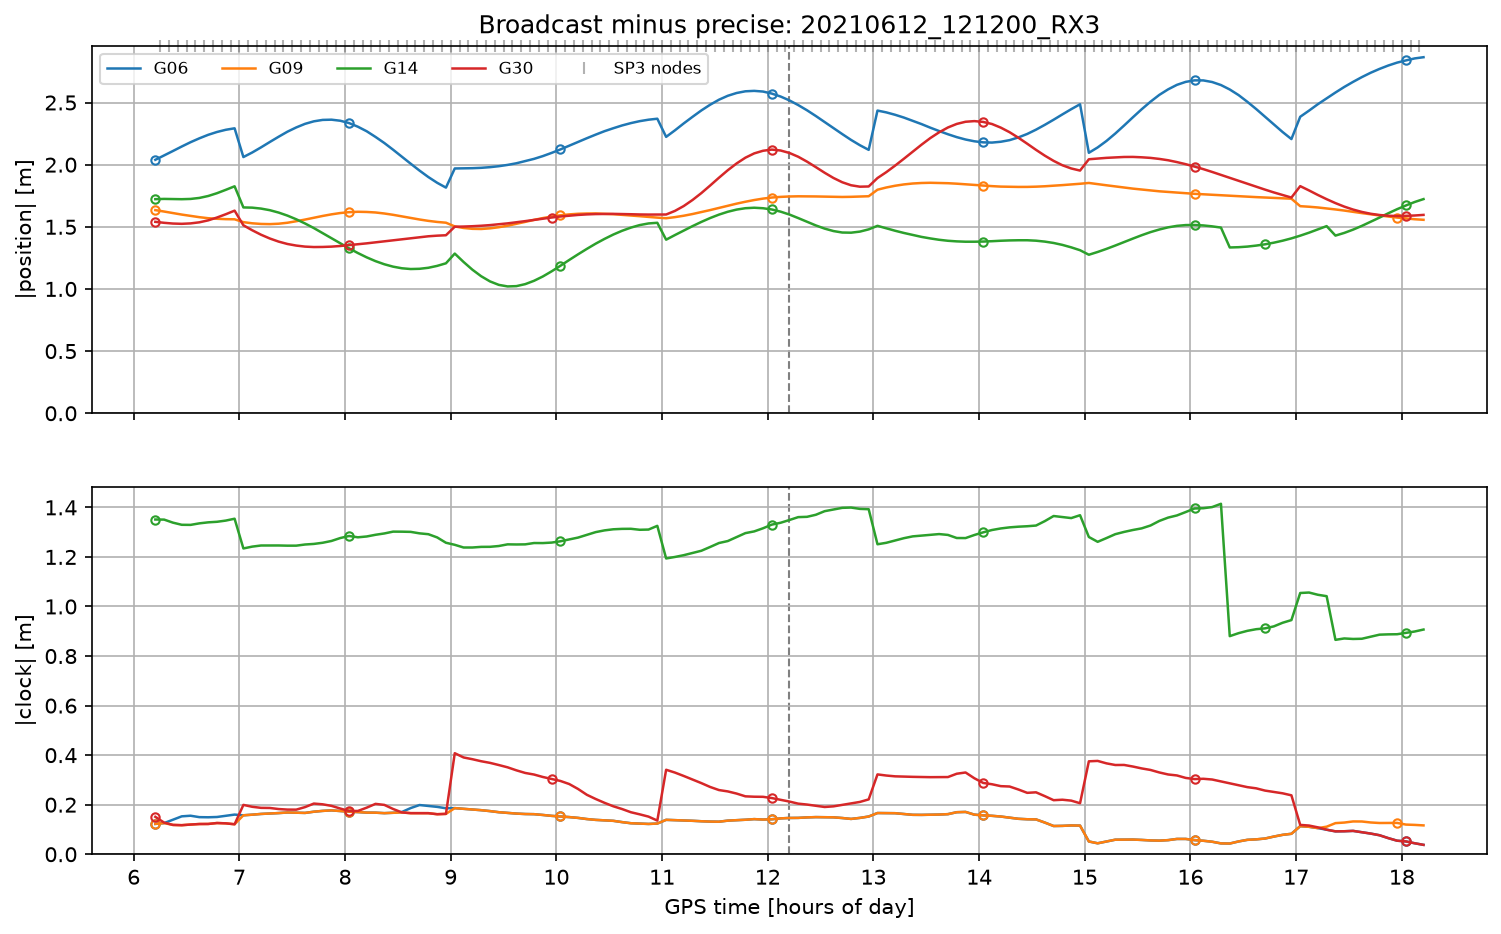

At the collect epoch. `clock` has the common offset removed; `clock, raw` does not:
  PRN  orbit [m]  clock [m]  clock, raw [m]
  ---  ---------  ---------  --------------
  G06       2.52       0.15           -0.29
  G09       1.74       0.15           +0.00
  G14       1.60       1.35           +1.20
  G30       2.09       0.21           -0.36
  common offset -0.14 m (-0.5 ns) of time-scale difference, which the
  receiver clock solution absorbs and the fix never sees.


In [9]:
if not USE_PRECISE_ORBIT_CHECK:
    print("Skipped (USE_PRECISE_ORBIT_CHECK is False). The fix below is unaffected;")
    print("it runs on the broadcast ephemeris either way.")
else:
    try:
        from gnss_tools.orbits.sp3_utils import download_and_parse_sp3_data
        from utils import precise_orbits

        # Hours either side of the collect, at 5-minute steps -- fine enough to show
        # an upload as a step rather than a corner, coarse enough that a degree-10
        # interpolation per satellite per point stays instant.
        span_s = ORBIT_COMPARISON_SPAN_HOURS * 3600.0
        offsets_s = np.arange(-span_s, span_s + 1.0, 300.0)
        gps_seconds_0 = week * 604800.0 + reference_tow   # SP3 tabulates full GPS seconds
        gps_seconds = gps_seconds_0 + offsets_s

        # Fetch it ourselves, into the directory sp3_utils caches in, so that its own
        # (credential-less, and therefore broken) download never runs.  A window that
        # crosses midnight needs the neighbouring day as well.
        for day_offset in {0, int(np.floor(offsets_s[0] / 86400.0)),
                           int(np.ceil(offsets_s[-1] / 86400.0))}:
            precise_orbits.download_sp3(collect_date + timedelta(days=day_offset))
        resources = str(utils.environment_variables.get_resources_path())
        sp3 = download_and_parse_sp3_data(gps_seconds[0], gps_seconds[-1], resources)
        print(f"SP3: {len(sp3.epochs)} epochs at "
              f"{np.diff(np.asarray(sp3.epochs))[0] / 60:.0f}-minute spacing, "
              f"{len(sp3.position)} satellites (all constellations)")

        # Which record a receiver would have been using at each instant.  Without this
        # the plot would show one ephemeris propagated across a whole day -- the aging
        # of a single upload, not what broadcast ephemeris is worth.  Records are
        # rebuilt only when the selection changes, which is a dozen times a day.
        def ephemeris_at(sat_id, tow_s, week_num, _cache={}):
            available = records.get(int(sat_id.lstrip("G")))
            if not available:
                return None
            record = broadcast_ephemeris.select_ephemeris(available, tow_s, week_num)
            if record is None:
                return None
            key = (sat_id, id(record))
            if key not in _cache:
                _cache[key] = broadcast_ephemeris.from_rinex(record, sat_id)
            return _cache[key]

        sat_ids = sorted(broadcast)
        position_diff_m = np.full((len(offsets_s), len(sat_ids)), np.nan)
        clock_diff_m = np.full((len(offsets_s), len(sat_ids)), np.nan)
        # The `toe` of every record each satellite used.  Marking those rather than the
        # handovers puts the circle where the data set's fit is centred, and leaves the
        # handovers where they belong, halfway between two circles.
        toes_by_sat = [set() for _ in sat_ids]

        # A span of hours can cross the end of a GPS week, so each instant carries its
        # own week and time of week rather than an offset from one reference.
        weeks = np.floor(gps_seconds / 604800.0).astype(int)
        tows = gps_seconds - weeks * 604800.0

        for j, sid in enumerate(sat_ids):
            if sid not in sp3.position:
                print(f"  {sid}: not in the SP3 file")
                continue
            truth = precise_orbits.interpolate_position_m(sp3, sid, gps_seconds)
            precise_clock_s = precise_orbits.interpolate_clock_s(sp3, sid, gps_seconds)
            for i, (tow, week_num) in enumerate(zip(tows, weeks)):
                eph = ephemeris_at(sid, tow, week_num)
                if eph is None or not np.isfinite(truth[i]).all():
                    continue
                toes_by_sat[j].add(week_num * 604800.0 + eph.toe)
                state = eph.orbit_state(tow)
                position_diff_m[i, j] = np.linalg.norm(
                    state.position_ecef_m - truth[i]
                )
                # The POLYNOMIAL, not the full clock correction.  An SP3 clock omits
                # the periodic relativistic term exactly as the broadcast parameters
                # do -- both leave it to the receiver -- so including it on one side
                # only would add a sinusoid at the orbital period.  Section 7 puts it
                # back where it belongs, in the pseudorange correction.
                #
                # Both sides also exclude group delay: the broadcast polynomial and
                # the IGS clock both describe the ionosphere-free P1/P2 combination,
                # and T_GD and the inter-signal corrections move that onto one signal.
                clock_diff_m[i, j] = (
                    eph.clock_polynomial_s(tow) - precise_clock_s[i]
                ) * SPEED_OF_LIGHT

        # A `toe` falls between two samples of the grid above, so each is marked on the
        # nearest one -- within half a sample interval, invisible at this span.
        ephemeris_toe_marks = np.zeros(position_diff_m.shape, dtype=bool)
        for j, toes in enumerate(toes_by_sat):
            for toe_gps_s in toes:
                ephemeris_toe_marks[int(np.argmin(np.abs(gps_seconds - toe_gps_s))), j] = True

        # The two time scales differ by an offset every satellite shares, which the
        # receiver clock solution absorbs whole.  Removing it per epoch leaves the part
        # that actually reaches the fix.  Median rather than mean: with a handful of
        # satellites one bad clock prediction drags a mean far enough to make every
        # other satellite look offset.
        common_offset_m = np.nanmedian(clock_diff_m, axis=1, keepdims=True)
        clock_departure_m = np.abs(clock_diff_m - common_offset_m)

        # Hours of the GPS day, measured from the midnight the collect falls in.
        # Absolute rather than relative to the collect, so a `toe` reads straight off
        # the axis; computed from full GPS seconds so a span crossing the end of a week
        # stays monotonic (and one crossing midnight simply runs past 24).
        day_start_gps_s = np.floor(gps_seconds_0 / 86400.0) * 86400.0
        def hours_of_day(gps_s):
            return (np.asarray(gps_s, dtype=float) - day_start_gps_s) / 3600.0

        fig = plt.figure(figsize=(12, 7), dpi=150)
        utils.plotting.plot_orbit_and_clock_differences(
            fig, hours_of_day(gps_seconds), position_diff_m, clock_departure_m,
            sat_ids,
            title=f"Broadcast minus precise: {collect_id}",
            sp3_epochs=hours_of_day(sp3.epochs),
            ephemeris_toe_marks=ephemeris_toe_marks,
            mark_time=hours_of_day(gps_seconds_0),
        )
        plt.show()

        # The table reports the collect itself -- the one instant the fix used --
        # rather than an average over a day that includes ephemerides this receiver
        # never saw.
        at_collect = int(np.argmin(np.abs(offsets_s)))
        tables.print_table(
            ["PRN", "orbit [m]", "clock [m]", "clock, raw [m]"],
            [[sid,
              f"{position_diff_m[at_collect, j]:.2f}"
              if np.isfinite(position_diff_m[at_collect, j]) else None,
              f"{clock_departure_m[at_collect, j]:.2f}"
              if np.isfinite(clock_departure_m[at_collect, j]) else None,
              f"{clock_diff_m[at_collect, j]:+.2f}"
              if np.isfinite(clock_diff_m[at_collect, j]) else None]
             for j, sid in enumerate(sat_ids)],
            caption="At the collect epoch. `clock` has the common offset removed; "
                    "`clock, raw` does not:",
        )
        offset_m = float(common_offset_m[at_collect, 0])
        print(f"  common offset {offset_m:+.2f} m "
              f"({offset_m / SPEED_OF_LIGHT * 1e9:+.1f} ns) of time-scale difference, "
              "which the\n  receiver clock solution absorbs and the fix never sees.")
    except Exception as exc:
        print(f"Precise orbit check unavailable: {type(exc).__name__}: {exc}")
        print("It needs a separate CDDIS download; nothing below depends on it.")

## 6. Skyplot

Where the satellites were, from the antenna's point of view. Two things to read off
it: **geometry** — fixes are precise in the directions satellites are spread across
and imprecise where they are not, which is what DOP puts a number on later — and
**what the front end managed**, since every satellite above the horizon is drawn and
the ones actually acquired are highlighted and coloured by tracked C/N0. Which
satellites get missed says as much about the antenna pattern as about the receiver.

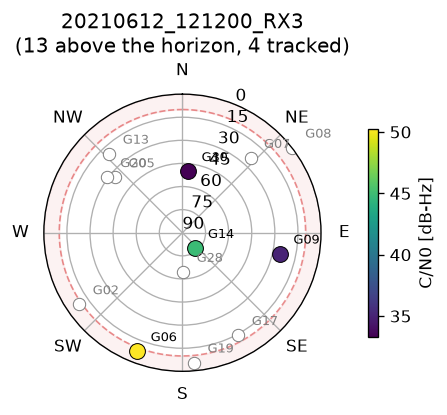

Tracked satellites:
  PRN  elevation [deg]  azimuth [deg]  C/N0 [dB-Hz]
  ---  ---------------  -------------  ------------
  G06              7.9         -158.8          50.3
  G09             25.4          101.6          35.0
  G14             76.9          143.1          44.8
  G30             50.1            4.8          33.3


In [10]:
# Every GPS satellite with a usable ephemeris, whether this receiver saw it or not.
all_visible = broadcast_ephemeris.ephemerides_for(
    [f"G{prn:02d}" for prn in range(1, 33)],
    reference_tow, week, epoch_datetime, records=records, verbose=False,
)

# A track, not a point: a GPS satellite moves a few degrees in a minute, which is
# visible over this collect and worth drawing.
track_times = reference_tow + np.linspace(0.0, run.shortest_duration_ms * 1e-3, 12)
azimuth, elevation = {}, {}
for sid, eph in all_visible.items():
    positions = np.array([eph.orbit_state(t).position_ecef_m for t in track_times])
    az, el = navigation.sky_positions(reference_ecef, positions)
    if el.max() > 0:
        azimuth[sid], elevation[sid] = az, el

# Mean C/N0 over the tracked span, on the data component.
cn0 = {}
for sid in run.signal_ids:
    values = run[sid].outputs.cn0_dbhz[run[sid].outputs.cn0_valid]
    if len(values):
        cn0[sid] = float(np.nanmean(values[:, 0]))

fig = plt.figure(figsize=(5, 3), dpi=120)
utils.plotting.plot_skyplot(
    fig, azimuth, elevation,
    cn0_dbhz=cn0,
    tracked=run.signal_ids,
    title=f"{collect_id}\n({len(azimuth)} above the horizon, {len(run)} tracked)",
)
plt.show()

tables.print_table(
    ["PRN", "elevation [deg]", "azimuth [deg]", "C/N0 [dB-Hz]"],
    [[sid,
      f"{elevation[sid].mean():.1f}" if sid in elevation else "no ephemeris",
      f"{azimuth[sid].mean():.1f}" if sid in elevation else None,
      f"{cn0[sid]:.1f}" if sid in cn0 else None]
     for sid in sorted(run.signal_ids)],
    caption="Tracked satellites:",
)

## 7. Pseudoranges

A pseudorange is `c × (t_receive − t_transmit)`, and almost none of it is the distance to
the satellite. Six things have to come out — and one deliberately stays in.

| Error source | Size | Where it comes from | How it is removed |
|---|---|---|---|
| **Satellite clock offset** | tens of km | every SV runs its own free clock, tens to hundreds of microseconds from GPS time | the quadratic `af0 + af1·(t−toc) + af2·(t−toc)²` the satellite broadcasts about itself |
| **Relativistic periodic term** | up to ±8 m | an eccentric orbit means the SV's clock speeds up and slows down over each revolution | `F·e·√A·sin(E)`, from the orbit — which is why the clock needs the eccentric anomaly |
| **Sagnac / earth rotation** | ~30 m | the earth turns during the ~70 ms the signal is in flight | rotate the transmit position by `−Ω·τ` into the frame as it stood at reception |
| **Troposphere** | ~2.5 m at the zenith, 10× that near the horizon | neutral atmosphere, and **not dispersive** — no frequency pair removes it | Saastamoinen with a standard atmosphere, mapped by elevation |
| **Ionosphere** | metres to tens of metres | free electrons, dispersive as `1/f²` — worst on L5, least on L1 | Klobuchar, with the coefficients this receiver decoded (or the broadcast file's) |
| **Group delay** | a metre or less | the broadcast clock describes the ionosphere-free P1/P2 combination, not the signal tracked | `T_GD` and the inter-signal correction |

Sagnac needs the transit time and the atmosphere needs an elevation, so both use
`RECEIVER_REFERENCE_GEO`. A kilometre of error there moves the tropospheric delay by well
under a millimetre, so the circularity is harmless.

**What stays in: the receiver clock bias**, which is the whole reason this is a
*pseudo*range. It is identical on every satellite at a given epoch, so it cannot be
modelled away — it is solved as a fourth unknown in sections 8 and 9. Also still in,
because nothing here can model them: multipath, the residual ephemeris and satellite-clock
error section 5 measured, and thermal noise. Those are what the residuals are made of.

### The plot

Correcting a pseudorange removes the **errors**, not the **geometry** — and the geometry
is not an error, it is the signal. A corrected pseudorange is still 20,200 km at the
zenith and 25,800 km near the horizon, so plotting it directly gives one line per
satellite thousands of kilometres apart, saying only which satellite is where. So the plot
subtracts the modelled range to `RECEIVER_REFERENCE_GEO` as well, leaving what the
position solve actually works on — two parts:

- **The bundle**, common to every satellite: the **receiver clock bias**. Its level is
  arbitrary, but its *slope* is real, and is the oscillator's rate error. A tenth of a ppm
  moves it tens of metres a second, so a few minutes of run is kilometres of ramp.
- **The spread within the bundle**: the a-priori position error projected onto each line
  of sight, plus ephemeris error, multipath and noise. Tens of metres with an unsurveyed
  reference, varying smoothly with satellite direction because a position error projects
  as a cosine.

Note the ratio — kilometres of ramp against tens of metres of spread — so on a long run
the lines look like one line. That is the honest size of the two terms, and it is why
section 9 holds the position fixed and gives the spread an axis of its own.

  epochs                  1,200 at 100 ms
  satellites              4: G06, G09, G14, G30
  Klobuchar coefficients  decoded from the signal


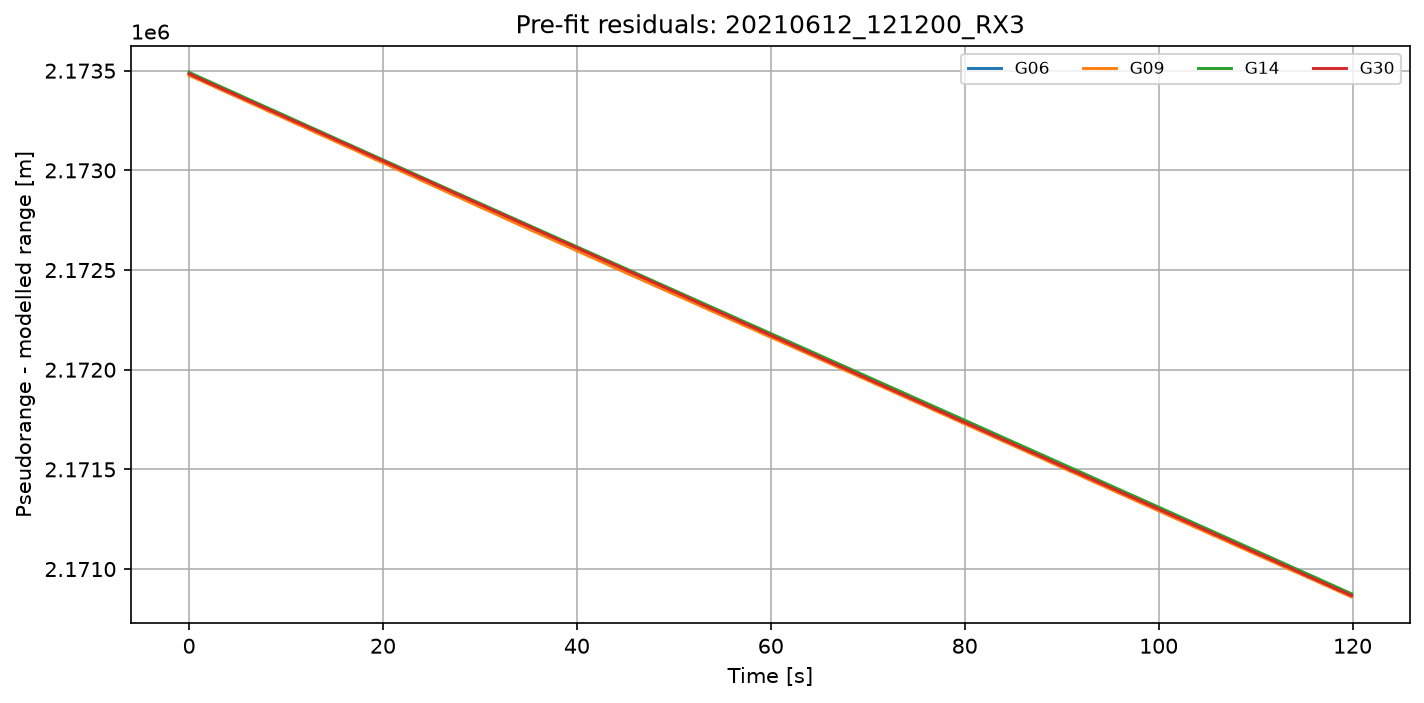

In [11]:
obs = observables.form_observables(
    {sid: run[sid].outputs for sid in anchors},
    anchors,
    epoch_interval_ms=EPOCH_INTERVAL_MS,
    week=week,
)

# Klobuchar coefficients, preferably ones this receiver decoded for itself.  Both
# message formats carry the same eight numbers, in different places: CNAV puts them in
# the 30-series clock messages, LNAV in subframe 4 page 18.
iono_alpha = iono_beta = None
for sid, result in decodes.items():
    if not result.synced:
        continue
    if MESSAGE_FORMAT == "CNAV":
        clocks = [m for m in result.messages if 30 <= m.message_type <= 37]
        if clocks:
            parsed = cnav.parse_type_30(clocks[0])
            iono_alpha, iono_beta = parsed.alpha, parsed.beta
            break
    else:
        # parse_iono_utc returns None for any subframe 4 page that is not 18, so
        # sweeping every decoded subframe is the intended use.  That page comes round
        # once every 12.5 minutes, so on a short capture it usually misses.
        for subframe in result.subframes:
            parsed = lnav.parse_iono_utc(subframe)
            if parsed is not None:
                iono_alpha, iono_beta = parsed.alpha, parsed.beta
                break
        if iono_alpha is not None:
            break

iono_source = "decoded from the signal"
if iono_alpha is None:
    # The same eight numbers out of the broadcast file's header.  They are updated at
    # most every few days, so this is the model the satellites were transmitting -- it
    # just did not arrive in the window this receiver heard.
    header_iono = broadcast_ephemeris.load_brdc_iono(collect_date)
    if header_iono is not None:
        iono_alpha, iono_beta = header_iono
        iono_source = "from the broadcast file header"
    else:
        iono_source = "unavailable"

corrected, terms = navigation.correct_pseudoranges(
    obs, broadcast,
    signal_type_id=SIGNAL_ID.signal_type_id,
    settings=CORRECTIONS,
    receiver_position_ecef_m=reference_ecef,
    iono_alpha=iono_alpha,
    iono_beta=iono_beta,
)

tables.print_fields(
    [("epochs", f"{len(obs.epoch_uptime_ms):,} at {EPOCH_INTERVAL_MS:g} ms"),
     ("satellites", f"{len(obs.sat_ids)}: {', '.join(obs.sat_ids)}"),
     ("Klobuchar coefficients", iono_source)],
)

# The corrections remove the errors, not the geometry -- so `corrected` is still
# 20,000-26,000 km, and plotting it shows nothing but which satellite is where.
# Subtracting the modelled range to the a-priori position leaves what a solve works on.
satellite_ecef_m = navigation.satellite_positions(
    obs, broadcast, apply_sagnac=CORRECTIONS.sagnac,
    # The a-priori is what makes the Sagnac transit geometric rather than taken
    # from the receiver clock, which is still carrying its bias at this point.
    receiver_position_ecef_m=reference_ecef,
)
geometric_range_m = np.linalg.norm(satellite_ecef_m - reference_ecef, axis=2)

fig = plt.figure(figsize=(11, 5), dpi=150)
utils.plotting.plot_prefit_residuals(
    fig,
    (obs.epoch_uptime_ms - obs.epoch_uptime_ms[0]) * 1e-3,
    corrected - geometric_range_m,
    obs.sat_ids,
    title=f"Pre-fit residuals: {collect_id}",
)
plt.show()

## 8. Position solution

Four unknowns — three of position, one of clock — from four or more pseudoranges, by
Newton's method on the geometry.

**DOP** is how geometry turns measurement error into position error: a fix is precise
in the directions the satellites are spread across. VDOP always exceeds HDOP for a
ground receiver, because every satellite is above the antenna and none below, which is
why vertical scatter is the largest of the three. Expect HDOP around 1 and VDOP around
2 with good geometry; a DOP in the tens means the satellites are clustered, and the fix
will wander in the direction they are missing from — worth checking against the
skyplot before blaming anything else.

**Residuals** are the diagnostic, and it is their structure that matters: scatter about
zero is measurement noise; one satellite consistently off is an ephemeris or multipath
problem on that satellite; all of them drifting together means something common-mode is
unmodelled. But with four unknowns solved from four or five measurements there is
little or no redundancy, so the post-fit residuals here are *forced small by the
geometry*. Section 9's, with the position held, are the honest ones.

**Offset from the reference** is a sanity check on the chain, not a measurement of
accuracy — unless `RECEIVER_REFERENCE_GEO` is surveyed. If two different signals on
the same antenna agree on an offset, that is evidence about the reference coordinates
rather than about the receiver.

> **If fewer than four satellites survived to here**, no position fix exists. The next
> cell says so and moves on; section 9 still produces a clock solution, because
> holding the position fixed removes three of the four unknowns.

In [12]:
can_fix_position = len(obs.sat_ids) >= 4

if not can_fix_position:
    print(f"Only {len(obs.sat_ids)} satellite(s) with both a decoded time and an "
          f"ephemeris: {', '.join(obs.sat_ids)}.\n"
          "Four are needed for a position fix. Skipping to section 9, which holds the\n"
          "position at the reference and solves the clock alone -- one satellite is\n"
          "enough for that, and its residuals are more informative than a fix's.")
    solution = None
else:
    solution = navigation.solve_series(
        obs, broadcast,
        signal_type_id=SIGNAL_ID.signal_type_id,
        settings=CORRECTIONS,
        initial_position_ecef_m=reference_ecef,
        iono_alpha=iono_alpha,
        iono_beta=iono_beta,
    )

    good = solution.valid
    mean_ecef = solution.position_ecef_m[good].mean(axis=0)
    lat, lon, height = navigation.ecef_to_geodetic(mean_ecef)

    tables.print_fields(
        [("epochs solved", f"{good.sum():,} of {len(good):,}"),
         ("mean fix", f"{lat:.6f} deg N, {lon:.6f} deg E, {height:,.1f} m"),
         ("reference", f"{RECEIVER_REFERENCE_GEO[0]:.6f} deg N, "
                       f"{RECEIVER_REFERENCE_GEO[1]:.6f} deg E, "
                       f"{RECEIVER_REFERENCE_GEO[2]:,.1f} m"),
         ("offset", f"{np.linalg.norm(mean_ecef - reference_ecef):,.1f} m")],
    )
    tables.print_table(
        ["GDOP", "PDOP", "HDOP", "VDOP", "TDOP"],
        [[f"{np.nanmean(solution.dop[name][good]):.2f}"
          for name in ("gdop", "pdop", "hdop", "vdop", "tdop")]],
        aligns=">>>>>",
        caption="\nDilution of precision, mean over the run:",
    )

    if len(obs.sat_ids) == 4:
        print("\nExactly four satellites: the fix is exactly determined, so the post-fit")
        print("residuals below are zero by construction and carry no information.")

  epochs solved  1,200 of 1,200
  mean fix       20.706464 deg N, -156.256831 deg E, 3,040.0 m
  reference      20.706409 deg N, -156.256923 deg E, 3,059.3 m
  offset         22.4 m

Dilution of precision, mean over the run:
  GDOP  PDOP  HDOP  VDOP  TDOP
  ----  ----  ----  ----  ----
  3.14  2.76  1.74  2.14  1.51

Exactly four satellites: the fix is exactly determined, so the post-fit
residuals below are zero by construction and carry no information.


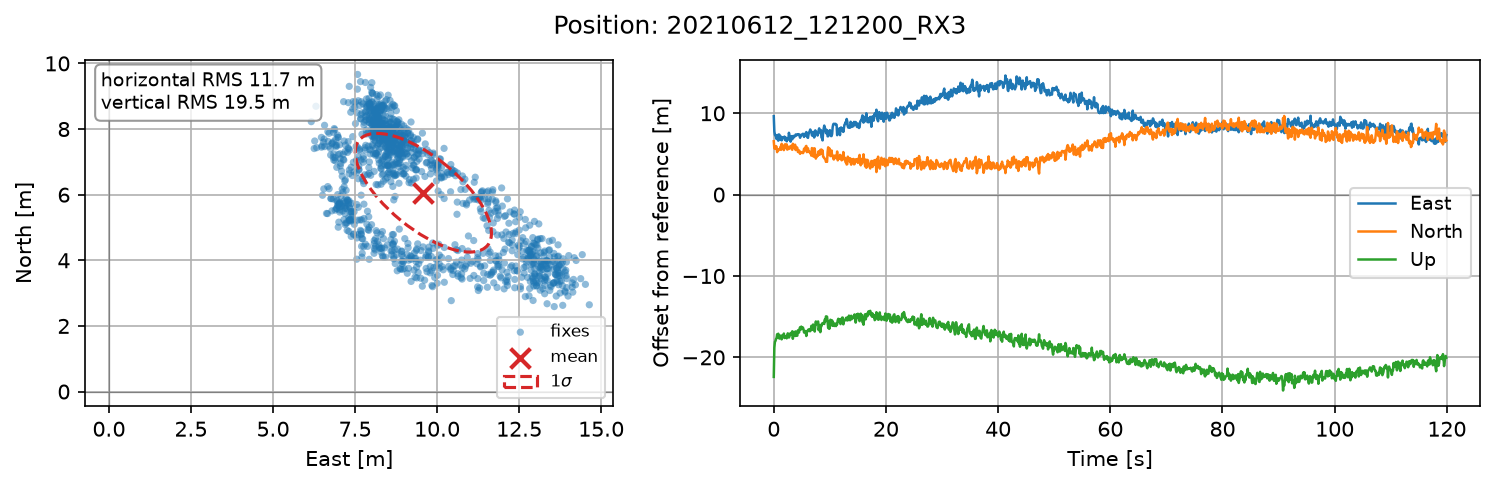

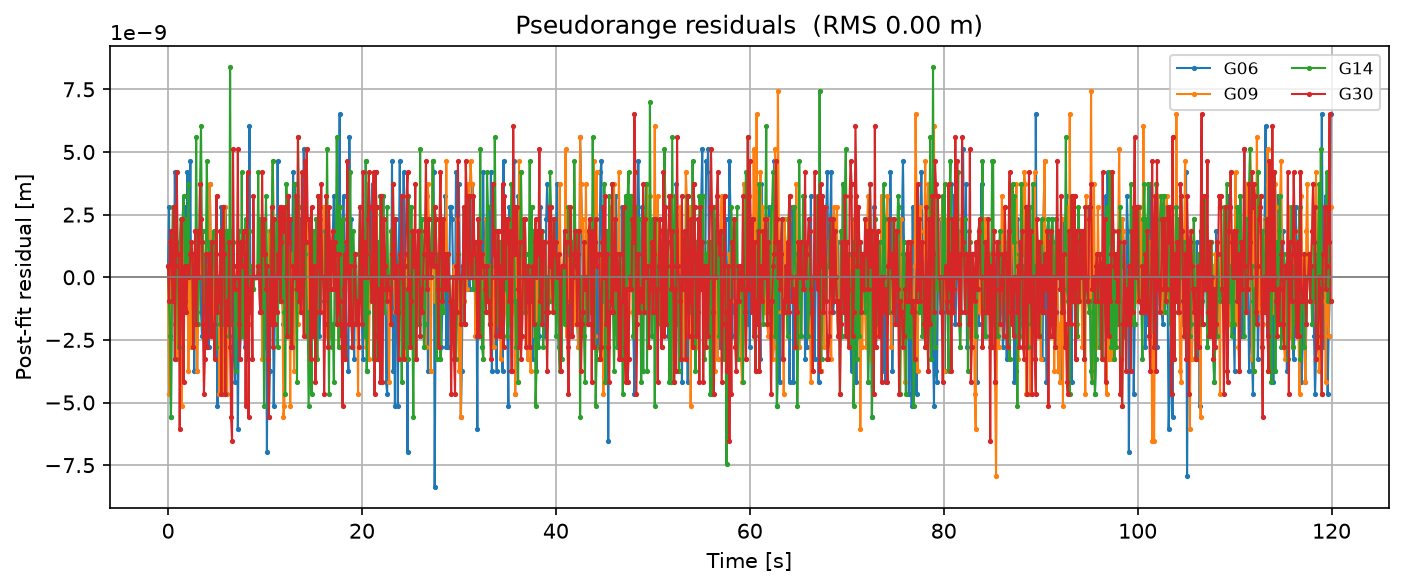

In [13]:
if solution is None:
    print("No position solution to plot -- see the cell above.")
else:
    enu = solution.enu_about(reference_ecef)
    position_time_s = (solution.epoch_uptime_ms - solution.epoch_uptime_ms[0]) * 1e-3
    fig = plt.figure(figsize=(12, 3), dpi=150)
    utils.plotting.plot_position_enu(
        fig, enu, position_time_s, title=f"Position: {collect_id}"
    )
    plt.show()

    fig = plt.figure(figsize=(11, 4), dpi=150)
    utils.plotting.plot_pseudorange_residuals(
        fig, position_time_s, solution.residuals_m, obs.sat_ids
    )
    plt.show()

## 9. Clock solution

The receiver's clock is the sample counter, so this is a measurement of the front end's
oscillator. The **slope** is its rate error in parts per million — a free-running TCXO of
the kind in an SDR front end is typically within a few ppm, an OCXO far better — and the
**residual** about that line is what a constant rate does not explain: measurement noise,
plus any real instability. Where several bands were recorded through one reference
oscillator, every band should return the same drift.

The position is **held** here. Held means *fixed at a value the solver is given and not
allowed to change*, rather than estimated: section 8 solved four unknowns, three of
position and one of clock, while this solves one and is told the other three. It is how a
timing receiver at a surveyed site runs permanently.

Two reasons, and the second matters even when a full fix was available:

- **One satellite is enough**, so a clock solution exists whatever the satellite count.
- **The residuals become informative**, which is a degrees-of-freedom count. Four
  measurements against four unknowns leave none: least squares fits every one of them
  exactly, and the error that should have shown up is absorbed into the position instead
  — section 8's post-fit residuals come out around 1e-9 m and mean nothing. The same four
  measurements against one unknown leave three degrees of freedom, and the solver can
  only shift them all by a single common number. Whatever is not common has nowhere to
  go, so it appears. On the L5 run here that is the difference between a residual RMS of
  2e-9 m and one of 2.2 m, from identical pseudoranges.

**What is held is section 8's own fix, averaged over the run** — not
`RECEIVER_REFERENCE_GEO`. The reference is a map coordinate, and unless it has been
surveyed its error projects onto every line of sight and dominates 9.3's `mean` column,
burying the measurement errors underneath it. The averaged fix is a better estimate of
where the antenna actually was, and the averaging is what makes it usable: a single
epoch's fix carries that epoch's noise, a mean over the run does not. Both positions are
solved and 9.3 prints both, because the difference between the two is the reference's own
error. Where no fix was possible the reference is held instead, and the cell says so.

### 9.1 The independent cross-check, and why its sign flips

One reference oscillator drives both the sampling clock and the downconverting LO, so a
rate error δ shows up twice, with **opposite** signs:

- **In time.** A fast sample clock makes receiver time run ahead of GPS time, so the clock
  bias grows: slope `+δ·c`.
- **In frequency.** The LO is also high, at `f_nom·(1 + δ)`, so everything downconverts
  too low: every satellite's Doppler is offset by `−δ·f_carrier`.

One ppm is one part per million *of the carrier* — 1575 Hz on L1, 1228 on L2, 1176 on L5 —
so even a fraction of a ppm is hundreds of hertz of common-mode Doppler, next to real
satellite Doppler of a few kHz. The two numbers should have the same magnitude and
opposite signs.

### 9.2 How to read the Doppler table

`measured` is what the carrier loops tracked; `predicted` is what the satellite's own
motion accounts for, from the ephemeris and the reference position. Both run to ±5 kHz and
change sign as a satellite passes overhead.

**The `difference` column is the interesting one, and it should be nearly the same for
every satellite** — that common part is the oscillator, not the satellites. The spread
about it is ephemeris error plus the reference position being approximate; tens of hertz
is expected, and one satellite tens of hertz off on its own is a channel that was not
really locked.

If the common value came out near zero you would not have a perfect oscillator; you would
have a bug, because this and the clock solution's drift are two routes to the same
physical quantity — one from decoded time and ephemerides, the other from the carrier
tracking loops. That they agree is a check on the whole chain.

  position held at             section 8's mean fix
  distance from the reference  22.36 m


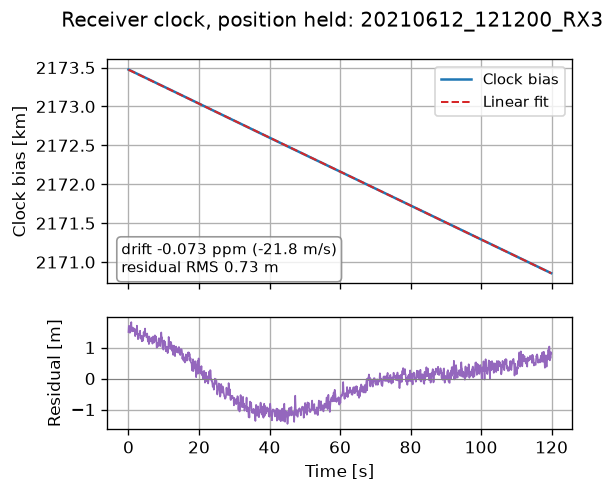

  clock drift                  -0.073 ppm
  residual RMS about the line  0.73 m
  one ppm on L5                1,176 Hz
  predicted Doppler offset     +86 Hz (note the sign flip)


In [14]:
# What to hold.  The reference is a map coordinate, so its error projects onto every
# line of sight and lands in 9.3's `mean` column -- usually as the largest term there.
# Section 8's own fix, averaged over the run, is a better estimate of where the
# antenna actually was, so hold that instead where it exists and keep the reference
# solution alongside for comparison.  Averaging is what makes it usable: a single
# epoch's fix carries that epoch's noise, and the mean over a run does not.
def _hold_at(position):
    return navigation.solve_clock_series(
        obs, broadcast, position,
        signal_type_id=SIGNAL_ID.signal_type_id,
        settings=CORRECTIONS,
        iono_alpha=iono_alpha,
        iono_beta=iono_beta,
    )


clock_at_reference = _hold_at(reference_ecef)
have_fix = solution is not None and solution.valid.any()
if have_fix:
    held_position = solution.position_ecef_m[solution.valid].mean(axis=0)
    held_label = "section 8's mean fix"
    clock = _hold_at(held_position)
else:
    # Nothing better to hold than the a-priori, so 9.3's two columns would be the
    # same numbers twice; it prints one.
    held_position, held_label = reference_ecef, "the reference"
    clock = clock_at_reference

fields = [("position held at", held_label)]
if have_fix:
    fields.append(("distance from the reference",
                   f"{np.linalg.norm(held_position - reference_ecef):,.2f} m"))
else:
    fields.append(("", "no position fix was available to average"))
tables.print_fields(fields)
time_s = (clock.epoch_uptime_ms - clock.epoch_uptime_ms[0]) * 1e-3

fig = plt.figure(figsize=(5, 4), dpi=120)
utils.plotting.plot_clock_solution(
    fig, time_s, clock.clock_bias_m,
    title=f"Receiver clock, position held: {collect_id}",
)
plt.show()

drift_ppm, rms_m = clock.clock_drift_ppm()
hz_per_ppm = SIGNAL_ID.carrier_freq_hz * 1e-6
tables.print_fields(
    [("clock drift", f"{drift_ppm:+.3f} ppm"),
     ("residual RMS about the line", f"{rms_m:.2f} m"),
     (f"one ppm on {SIGNAL_ID.link.id.value}", f"{hz_per_ppm:,.0f} Hz"),
     ("predicted Doppler offset", f"{-drift_ppm * hz_per_ppm:+,.0f} Hz "
                                  "(note the sign flip)")],
)

### 9.3 Residuals with the position held

The honest measurement diagnostic: each satellite's deviation from the common clock
offset, so an ephemeris error, a multipath fade or a low-elevation troposphere
mismodelling shows up on that satellite alone.

- **`mean, at reference`** is the residual with `RECEIVER_REFERENCE_GEO` held. Unless that
  coordinate is surveyed, its own error — projected onto each line of sight — is usually
  the largest term in this column, and it appears as a *static offset* rather than as
  scatter.
- **`mean, at held`** is the same quantity with section 8's averaged fix held instead. The
  reference's error is gone from it, so what is left belongs to the satellite: an
  ephemeris error, or a multipath geometry that does not change over a minute. **The
  difference between the two columns is the reference error**, satellite by satellite —
  and a difference varying smoothly with direction (compare against the skyplot) is a
  position error, because one projects as a cosine across the sky.
- **`scatter`** is what changes epoch to epoch: thermal noise and the tracking loops. It is
  printed once because it *cannot* depend on the held position — moving that position adds
  the same constant to every epoch of a satellite. A few metres is normal on a strong
  satellite; a low-elevation one is worse, both because its C/N0 is lower and because it
  looks through more troposphere. Tens of metres means that channel was barely holding
  lock, and it is dragging the fix in section 8 too.

> **With exactly four satellites, `mean, at held` is zero by construction** and carries no
> information: the fix that produced the held position was itself exactly determined by
> those same four measurements, so holding it forces their mean residuals to vanish. That
> is section 8's degeneracy moved rather than removed, and the cell says so when it
> happens. `scatter` is untouched by it and remains the column to read.

A satellite with `epochs` far below the others contributed to only part of the run, so its
`mean` averages a different stretch of time than everyone else's.

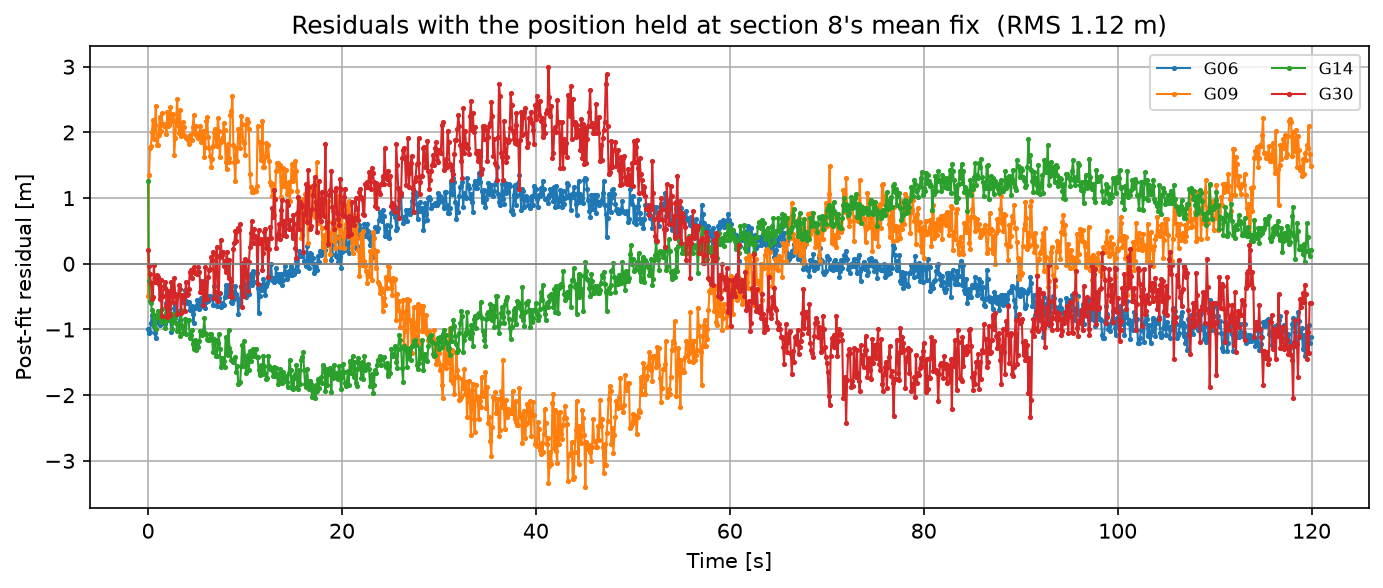

Per-satellite residual. The two means differ by the reference's own error,
projected onto that satellite's line of sight:
  PRN  mean, at reference [m]  mean, at held [m]  scatter [m]  epochs
  ---  ----------------------  -----------------  -----------  ------
  G06                   +1.29              -0.02         0.73   1,200
  G09                   -9.49              +0.01         1.38   1,200
  G14                   +8.19              +0.01         1.05   1,200
  G30                   +0.01              +0.01         1.23   1,200

Exactly four satellites, so `mean, at held` is zero by construction: the fix
that produced the held position was itself exactly determined by these four
measurements. It is the same degeneracy as section 8's residuals, moved. Read
`scatter`, which no choice of held position can flatter.


In [15]:
fig = plt.figure(figsize=(11, 4), dpi=150)
utils.plotting.plot_pseudorange_residuals(
    fig, time_s, clock.residuals_m, obs.sat_ids,
    title=f"Residuals with the position held at {held_label}",
)
plt.show()

# Two `mean` columns when there are two positions to hold, because the difference
# between them IS the reference's error.  `scatter` is printed once either way: it is
# a per-epoch quantity, and moving the held position adds the same constant to every
# epoch of a satellite, so it cannot change.
rows = []
for j, sid in enumerate(obs.sat_ids):
    held_col = clock.residuals_m[:, j][np.isfinite(clock.residuals_m[:, j])]
    ref_col = clock_at_reference.residuals_m[:, j]
    ref_col = ref_col[np.isfinite(ref_col)]
    row = [sid, f"{ref_col.mean():+.2f}" if len(ref_col) else None]
    if have_fix:
        row.append(f"{held_col.mean():+.2f}" if len(held_col) else None)
    row += [f"{held_col.std():.2f}" if len(held_col) else None, f"{len(held_col):,}"]
    rows.append(row)

headers = ["PRN", "mean, at reference [m]"]
headers += ["mean, at held [m]"] if have_fix else []
tables.print_table(
    headers + ["scatter [m]", "epochs"],
    rows,
    aligns="<" + ">" * (len(headers) + 1),
    caption=("Per-satellite residual. The two means differ by the reference's own "
             "error,\nprojected onto that satellite's line of sight:")
    if have_fix else "Per-satellite residual, with the reference held:",
)

if have_fix and len(obs.sat_ids) == 4:
    print("\nExactly four satellites, so `mean, at held` is zero by construction: the fix\n"
          "that produced the held position was itself exactly determined by these four\n"
          "measurements. It is the same degeneracy as section 8's residuals, moved. Read\n"
          "`scatter`, which no choice of held position can flatter.")

In [16]:
# Cross-check: the oscillator rate error should also show up as a common-mode offset
# between the Doppler tracked and the Doppler the satellite's own motion accounts for.
predicted, measured = [], []
for sid in obs.sat_ids:
    outputs = run[sid].outputs
    locked = outputs.pll_mode[outputs.valid]
    doppler = outputs.doppler_freq_hz[outputs.valid]
    measured.append(float(np.mean(doppler[locked])) if locked.any() else np.nan)

    eph, dt, t = broadcast[sid], 1.0, anchors[sid].tow_s
    before = eph.orbit_state(t - dt / 2).position_ecef_m
    after = eph.orbit_state(t + dt / 2).position_ecef_m
    line_of_sight = (before + after) / 2 - reference_ecef
    line_of_sight /= np.linalg.norm(line_of_sight)
    range_rate = np.dot((after - before) / dt, line_of_sight)
    predicted.append(-range_rate / SPEED_OF_LIGHT * SIGNAL_ID.carrier_freq_hz)

offsets = np.array(measured) - np.array(predicted)
tables.print_table(
    ["PRN", "measured [Hz]", "predicted [Hz]", "difference [Hz]"],
    [[sid,
      f"{m:+,.1f}" if np.isfinite(m) else None,
      f"{pr:+,.1f}",
      f"{o:+.1f}" if np.isfinite(o) else None]
     for sid, m, pr, o in zip(obs.sat_ids, measured, predicted, offsets)],
    caption="Doppler, tracked against what the satellite's own motion accounts for:",
)

common = np.nanmean(offsets)
implied_ppm = common / SIGNAL_ID.carrier_freq_hz * 1e6
tables.print_fields(
    [("common-mode Doppler", f"{common:+.1f} Hz"),
     ("Doppler implies", f"{implied_ppm:+.3f} ppm"),
     ("clock solution said", f"{drift_ppm:+.3f} ppm"),
     ("agreement", f"same magnitude, opposite sign, to "
                   f"{abs(abs(implied_ppm) - abs(drift_ppm)):.3f} ppm")],
    caption="\nTwo routes to the oscillator's rate error:",
)

Doppler, tracked against what the satellite's own motion accounts for:
  PRN  measured [Hz]  predicted [Hz]  difference [Hz]
  ---  -------------  --------------  ---------------
  G06       -1,338.4        -1,435.2            +96.8
  G09       -1,249.1        -1,322.1            +72.9
  G14         +581.9          +524.3            +57.6
  G30         -736.0          -817.6            +81.7

Two routes to the oscillator's rate error:
  common-mode Doppler  +77.3 Hz
  Doppler implies      +0.066 ppm
  clock solution said  -0.073 ppm
  agreement            same magnitude, opposite sign, to 0.007 ppm


---

## Exercises

1. **Turn a correction off.** Set `satellite_clock=False` in `CORRECTIONS` and re-run from
   section 7. Predict first: metres, kilometres, or a failure to converge? Then try
   `sagnac=False`, a much smaller change that moves the answer in a specific direction —
   which one, and why?
2. **Measurement rate.** Set `EPOCH_INTERVAL_MS` to 1000. The scatter should not change
   much but the clock drift estimate should get *worse*. Why does fewer points hurt a
   slope more than a mean?
3. **Drop a satellite.** Remove the highest-elevation satellite from `anchors` before
   section 7 and re-run; compare HDOP and VDOP. Now drop the lowest instead. Which costs
   more, and does DOP predict it?
4. **The ionosphere, twice.** Set `ionosphere=False` and note how far the fix moves. Do the
   same on another band of the same collect: the ratio should be the ratio of `1/f²`, about
   1.79 between L1 and L5. Check the direction too — it is mostly vertical.
5. **Where the residuals come from.** Estimate how much of section 8's residual is
   broadcast ephemeris error, using section 5's plot and remembering that only the
   line-of-sight part of an orbit error reaches the range while the clock error reaches it
   whole. How much is left?
6. **A shorter decode.** Re-run notebook `01` with a much smaller `TRACK_DURATION_MS` and
   come back, setting the same value here — the duration is part of the file name, so the
   short run lands beside the long one. Does the decode still find a message? Two? What
   breaks first, the time anchor or the ephemeris assembly? The answer differs by signal.
7. **The same fix from a different signal.** If your collect recorded more than one band,
   track and solve two of them. The satellites are not the same set and the ionosphere is
   not the same size, but the oscillator is one oscillator and the antenna has not moved —
   so the drift should agree and the two position clouds should overlap. Where they do not,
   which do you believe?

## Not covered here

**Carrier-phase positioning.** Tracking measures carrier phase to a fraction of a cycle —
millimetres of range — but with an unknown integer number of cycles. Resolving those
integers is what takes a receiver from metres to centimetres.

**RAIM and fault detection.** Five satellites against four unknowns give one degree of
redundancy, enough to notice a bad measurement but not to identify which one.

**Filtering.** Every epoch here is solved independently, which is why the scatter looks
like scatter. A Kalman filter carrying position and clock between epochs would use the
fact that neither changes much in 100 ms.

**Multi-frequency.** The largest error left in this fix is the ionosphere, and the real
answer is a second frequency: the ionosphere-free combination of two bands cancels the
`1/f²` term outright. A collect recording two bands through one oscillator holds the raw
material, but each band is tracked in its own run and written to its own file, so combining
them means pairing two `TrackingRun`s onto one measurement grid and matching satellites
across a set that is not the same on both. That is a notebook of its own.

**CNAV-2's ephemeris.** L1C's subframe 1 decodes fully, so its *time* is available, but
subframes 2 and 3 sit behind LDPC codes that are not implemented yet. See
`utils/nav/cnav2.py`.